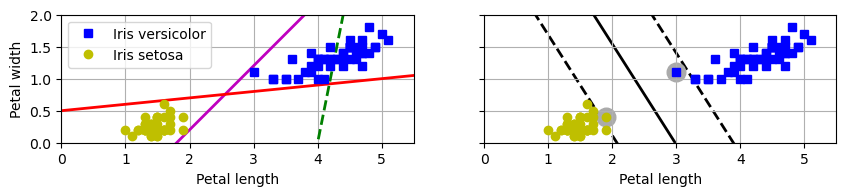

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM 분류 모델
svm_clf = SVC(kernel="linear")
svm_clf.fit(X, y)

# 나쁜 모델
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    # 결정 경계에서, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    plt.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_up, "k--", linewidth=2, zorder=-2)
    plt.plot(x0, gutter_down, "k--", linewidth=2, zorder=-2)
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA',
                zorder=-1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 2.7), sharey=True)

plt.sca(axes[0])
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()

plt.sca(axes[1])
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.xlabel("Petal length")
plt.axis([0, 5.5, 0, 2])
plt.gca().set_aspect("equal")
plt.grid()
plt.show()

In [6]:
# 결정트리
# 지니계수, 엔트로피
# 지니계수(불순도), 엔트로피(불확실성)
# 앙상블 : 배깅, 부스팅, 스태킹
# 차원축소 : PCA 차원의 저주 : 차원이 증가할수록 데이터가 희소해지는 현상  분산이 커지는 방향으로 새로운 축을 만들어서 투영

In [ ]:
# 오늘 학습한 모델을 전부 적용
# Dacon ->회귀


In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

base = Path('data')
train = pd.read_csv(base/'train.csv')
layout = pd.read_csv(base/'layout_info.csv')
target = 'avg_delay_minutes_next_30m'

print('=== LOAD & MERGE ===')
print(f"train shape: {train.shape}")
print(f"layout_info shape: {layout.shape}")
df = train.merge(layout, on='layout_id', how='left')
print(f"merged shape: {df.shape}")

df[target] = pd.to_numeric(df[target], errors='coerce')
df = df[df[target].notna()].reset_index(drop=True)

MAX_ROWS = 80000
if len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=42).reset_index(drop=True)
    print(f"sampled rows for execution speed: {len(df)}")

X = df.drop(columns=[target]).copy()
y = df[target].copy()

print('\n=== SPLITS ===')
X_tr_r, X_va_r, y_tr_r, y_va_r = train_test_split(X, y, test_size=0.2, random_state=42)
if 'scenario_id' in X.columns:
    groups = X['scenario_id'].astype(str).fillna('NA_GROUP')
    tr_idx, va_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42).split(X, y, groups=groups))
    X_tr_g, X_va_g = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
    y_tr_g, y_va_g = y.iloc[tr_idx].copy(), y.iloc[va_idx].copy()
else:
    X_tr_g, X_va_g, y_tr_g, y_va_g = X_tr_r.copy(), X_va_r.copy(), y_tr_r.copy(), y_va_r.copy()

splits = {'random_80_20': (X_tr_r, X_va_r, y_tr_r, y_va_r), 'group_scenario_80_20': (X_tr_g, X_va_g, y_tr_g, y_va_g)}

ratio_pairs = [
    ('order_inflow_15m','active_robot_count','ratio_order_inflow_15m_active_robot_count'),
    ('pending_order_count','active_robot_count','ratio_pending_order_count_active_robot_count'),
    ('charging_robot_count','active_robot_count','ratio_charging_robot_count_active_robot_count'),
    ('avg_aisle_congestion','active_robot_count','ratio_avg_aisle_congestion_active_robot_count'),
    ('picking_queue','picker_active','ratio_picking_queue_picker_active'),
    ('packing_queue','packer_active','ratio_packing_queue_packer_active'),
]
interaction_pairs = [
    ('order_inflow_15m','avg_aisle_congestion','inter_order_inflow_15m_x_avg_aisle_congestion'),
    ('pending_order_count','avg_aisle_congestion','inter_pending_order_count_x_avg_aisle_congestion'),
    ('order_inflow_15m','battery_low_robot_count','inter_order_inflow_15m_x_battery_low_robot_count'),
]

def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

def add_candidate_features(df_in):
    df_out = df_in.copy(); created=[]
    for n,d,newc in ratio_pairs:
        if n in df_out.columns and d in df_out.columns:
            df_out[newc] = safe_divide(pd.to_numeric(df_out[n], errors='coerce'), pd.to_numeric(df_out[d], errors='coerce')); created.append(newc)
    for a,b,newc in interaction_pairs:
        if a in df_out.columns and b in df_out.columns:
            df_out[newc] = pd.to_numeric(df_out[a], errors='coerce')*pd.to_numeric(df_out[b], errors='coerce'); created.append(newc)
    return df_out, created

results=[]

def add_result(split_name, fe_name, model_name, yt, yp):
    results.append({'split': split_name, 'fe': fe_name, 'model': model_name, 'mae': float(mean_absolute_error(yt, yp))})

try:
    from lightgbm import LGBMRegressor
    has_lgb=True
except:
    has_lgb=False
try:
    from catboost import CatBoostRegressor
    has_cat=True
except:
    has_cat=False
print(f"LightGBM available: {has_lgb}, CatBoost available: {has_cat}")

from tqdm import tqdm

for split_name,(Xtr_base,Xva_base,ytr,yva) in tqdm(splits.items()):
    for fe_name in ['base','fe_plus']:
        if fe_name=='base':
            Xtr,Xva,created = Xtr_base.copy(),Xva_base.copy(),[]
        else:
            Xtr,created = add_candidate_features(Xtr_base)
            Xva,_ = add_candidate_features(Xva_base)

        cat_cols = Xtr.select_dtypes(include=['object','category']).columns.tolist()
        num_cols = [c for c in Xtr.columns if c not in cat_cols]

        pre = ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), cat_cols)
        ], remainder='drop')
        hgb = Pipeline([('pre', pre), ('model', HistGradientBoostingRegressor(learning_rate=0.05,max_depth=10,max_iter=300,random_state=42,loss='absolute_error'))])
        hgb.fit(Xtr,ytr)
        add_result(split_name,fe_name,'HistGradientBoosting',yva,hgb.predict(Xva))

        if has_lgb:
            Xtr_l,Xva_l = Xtr.copy(),Xva.copy()
            for c in cat_cols:
                Xtr_l[c]=Xtr_l[c].astype('category'); Xva_l[c]=Xva_l[c].astype('category')
            lgb = LGBMRegressor(objective='mae', n_estimators=800, learning_rate=0.03, num_leaves=63, subsample=0.85, colsample_bytree=0.85, random_state=42, verbosity=-1)
            lgb.fit(Xtr_l,ytr,categorical_feature=cat_cols)
            add_result(split_name,fe_name,'LightGBM',yva,lgb.predict(Xva_l))

            shift = (-float(ytr.min())+1.001) if ytr.min()<=-1.0 else 0.0
            ylog = np.log1p(ytr+shift)
            lgb2 = LGBMRegressor(objective='mae', n_estimators=400, learning_rate=0.03, num_leaves=63, subsample=0.85, colsample_bytree=0.85, random_state=42, verbosity=-1)
            lgb2.fit(Xtr_l,ylog,categorical_feature=cat_cols)
            add_result(split_name,fe_name,'LightGBM_log1p_target',yva,np.expm1(lgb2.predict(Xva_l))-shift)

        if has_cat:
            idx=[Xtr.columns.get_loc(c) for c in cat_cols]
            cat=CatBoostRegressor(iterations=1200,depth=8,learning_rate=0.03,loss_function='MAE',eval_metric='MAE',random_seed=42,verbose=False)
            cat.fit(Xtr,ytr,cat_features=idx)
            add_result(split_name,fe_name,'CatBoost',yva,cat.predict(Xva))
            shift = (-float(ytr.min())+1.001) if ytr.min()<=-1.0 else 0.0
            ylog=np.log1p(ytr+shift)
            cat2=CatBoostRegressor(iterations=1200,depth=8,learning_rate=0.03,loss_function='MAE',eval_metric='MAE',random_seed=42,verbose=False)
            cat2.fit(Xtr,ylog,cat_features=idx)
            add_result(split_name,fe_name,'CatBoost_log1p_target',yva,np.expm1(cat2.predict(Xva))-shift)

res=pd.DataFrame(results).sort_values(['split','mae']).reset_index(drop=True)
print('\n=== SORTED RESULTS [split, fe, model, mae] ===')
print(res[['split','fe','model','mae']].to_string(index=False))

best = res.loc[res.groupby('split')['mae'].idxmin()].sort_values('split')
print('\n=== BEST RESULT PER SPLIT ===')
print(best[['split','fe','model','mae']].to_string(index=False))

print('\n=== TOP 15 ABS PEARSON CORR WITH TARGET ===')
num_df=df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)[target].drop(labels=[target], errors='ignore').dropna()
top = corr.reindex(corr.abs().sort_values(ascending=False).head(15).index)
print(pd.DataFrame({'feature':top.index,'pearson_corr':top.values,'abs_corr':top.abs().values}).to_string(index=False))


=== LOAD & MERGE ===
train shape: (250000, 94)
layout_info shape: (300, 15)
merged shape: (250000, 108)
sampled rows for execution speed: 80000

=== SPLITS ===
LightGBM available: True, CatBoost available: False


100%|██████████| 2/2 [03:26<00:00, 103.49s/it]



=== SORTED RESULTS [split, fe, model, mae] ===
               split      fe                 model      mae
group_scenario_80_20    base  HistGradientBoosting 9.064346
group_scenario_80_20 fe_plus  HistGradientBoosting 9.064346
group_scenario_80_20    base LightGBM_log1p_target 9.176822
group_scenario_80_20 fe_plus LightGBM_log1p_target 9.176822
group_scenario_80_20    base              LightGBM 9.184492
group_scenario_80_20 fe_plus              LightGBM 9.184492
        random_80_20    base              LightGBM 8.473150
        random_80_20 fe_plus              LightGBM 8.473150
        random_80_20    base LightGBM_log1p_target 8.563028
        random_80_20 fe_plus LightGBM_log1p_target 8.563028
        random_80_20    base  HistGradientBoosting 9.234289
        random_80_20 fe_plus  HistGradientBoosting 9.234289

=== BEST RESULT PER SPLIT ===
               split   fe                model      mae
group_scenario_80_20 base HistGradientBoosting 9.064346
        random_80_20 base    

In [16]:
# 최종 추천 모델 설정
final_model = Pipeline([
    ('pre', pre), 
    ('model', HistGradientBoostingRegressor(
        learning_rate=0.03, # 조금 더 세밀하게 학습
        max_iter=500,       # 반복 횟수 상향
        max_depth=10,
        random_state=42,
        loss='absolute_error',
        early_stopping=True # 과적합 방지
    ))
])

# 학습 데이터 전체(X_tr_g, y_tr_g)로 최종 모델 훈련
final_model.fit(X_tr_g, y_tr_g)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [21]:
submission = pd.DataFrame({'ID': test['ID'], TARGET: test_preds})
submission.to_csv('./submission.csv', index=False)
print("submission.csv 저장 완료.")

NameError: name 'test_preds' is not defined

In [27]:
X_tr_g.shape

(63983, 107)

In [28]:
test

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TEST_000000,WH_202,SC_10973,61.0,155.0,NaN,0.0000,0.0656,0.1311,0.3047,...,4.88,0.0534,4.93,0.2164,13.5,NaN,96.2,0.0374,0.00,97.74
1,TEST_000001,WH_202,SC_10973,59.0,108.0,NaN,NaN,0.0847,0.0847,0.3047,...,6.69,NaN,NaN,NaN,21.1,15.94,90.5,0.0522,3.03,NaN
2,TEST_000002,WH_202,SC_10973,95.0,200.0,3.35,0.0526,NaN,0.1053,0.3047,...,6.28,0.0534,8.57,0.2292,23.2,16.25,NaN,0.0649,1.36,95.31
3,TEST_000003,WH_202,SC_10973,59.0,166.0,4.20,0.0339,0.0508,0.1017,0.3047,...,7.92,0.0835,NaN,0.2045,NaN,15.57,NaN,0.0268,0.64,94.01
4,TEST_000004,WH_202,SC_10973,NaN,130.0,NaN,0.0200,0.0200,0.1000,0.3047,...,7.00,0.1684,NaN,0.2174,NaN,17.16,91.0,0.0533,0.25,95.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TEST_049995,WH_225,SC_10910,13.0,9.0,1.31,0.0000,0.0000,0.0000,NaN,...,4.59,0.2267,8.26,0.0450,18.3,NaN,84.8,NaN,NaN,95.08
49996,TEST_049996,WH_225,SC_10910,NaN,NaN,1.00,0.0000,0.3333,0.0000,0.2150,...,4.80,0.1775,6.18,0.0305,9.6,9.82,83.0,0.1309,9.64,94.56
49997,TEST_049997,WH_225,SC_10910,10.0,NaN,2.10,NaN,0.0000,0.0000,0.2150,...,5.71,0.2488,6.52,0.0536,9.4,NaN,86.9,0.1206,9.75,96.14
49998,TEST_049998,WH_225,SC_10910,17.0,15.0,NaN,NaN,0.2353,0.0000,0.2150,...,5.15,NaN,9.41,0.0881,20.1,12.96,81.9,0.1228,8.09,NaN


In [29]:
test.shape

(50000, 93)